# ***Scientometric Analysis of the BD Network***

This notebook contains the analyses reported in the main manuscript.
Reusable analysis and plotting logic is kept in `functions.py`.

Main analyses:

1. Publication output and author participation (Table 1)
2. Interrupted time-series analysis of publication output (Figure 1)
3. Matched post-2009 publication-growth analysis (Figure 2)
4. Annualized fractional author productivity (Figure 3)
5. BD Network co-authorship structure and yearly European network metrics (Figure 4 and Table 2)


## **Setup**

In [ ]:
%pip install -q pycountry adjustText statsmodels networkx scipy openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 27.9 MB/s eta 0:00:00


In [ ]:
import os
from pathlib import Path

from google.colab import drive

drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/')

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from IPython.display import display

import functions as fn

FIGURE_DIR = Path('Figures')
FIGURE_DIR.mkdir(exist_ok=True)

## **Configuration**

In [ ]:
PRE_START = 1992
INTERVENTION_YEAR = 2009
POST_END = 2025
N_SIMULATIONS = 10_000
RANDOM_SEED = 42
MIN_AFP_YEARS = 5

# Scopus Author IDs are the author identifiers.
author_registry = fn.load_author_registry('id_scopus.xlsx')
author_ids = author_registry['Scopus Author ID'].tolist()
id_to_surname = author_registry.set_index('Scopus Author ID')['Cognome'].to_dict()
first_publication_year = (
    author_registry.set_index('Scopus Author ID')['First publication year'].to_dict()
)

european_countries = [
    'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czech Republic',
    'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary',
    'Ireland', 'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta',
    'Netherlands', 'Norway', 'Poland', 'Portugal', 'Romania', 'Slovakia',
    'Slovenia', 'Spain', 'Sweden', 'Turkey', 'United Kingdom',
]

display(author_registry[['Scopus Author ID', 'Sur']])

,Scopus Author ID,Cognome
0,56600076200,Andreassen
1,57225888130,Arat-Çelik
2,59495201800,Bayas
3,56431978500,Bauer
4,6601968099,Bechdolf
5,56249550600,Bellivier
6,8961530500,Bergink
7,7005414125,Blumberg
8,56198886800,Ceylan
9,57219660986,De Prisco


## **Load and preprocess the four Scopus datasets**

In [ ]:
df_pre_bd = fn.preprocess_and_save(
    'data/bd-net-pubblications1992-2008',
    'Data_processed',
    'bd-1992-2008.csv',
    author_ids,
    european_countries,
)
df_post_bd = fn.preprocess_and_save(
    'data/bd-net-pubblications2009-2025',
    'Data_processed',
    'bd-2009-2025.csv',
    author_ids,
    european_countries,
)

df_pre = fn.preprocess_and_save(
    'data/Pubblications1992-2008',
    'Data_processed',
    '1992-2008.csv',
    author_ids,
    european_countries,
)
df_post = fn.preprocess_and_save(
    'data/Pubblications2009-2025',
    'Data_processed',
    '2009-2025.csv',
    author_ids,
    european_countries,
)

df_pre = df_pre[df_pre['Year'].between(PRE_START, INTERVENTION_YEAR - 1)].copy()
df_post = df_post[df_post['Year'].between(INTERVENTION_YEAR, POST_END)].copy()
df_pre_bd = df_pre_bd[df_pre_bd['Year'].between(PRE_START, INTERVENTION_YEAR - 1)].copy()
df_post_bd = df_post_bd[df_post_bd['Year'].between(INTERVENTION_YEAR, POST_END)].copy()

df_pre_bd = df_pre_bd[df_pre_bd['BD-Authors'] != 0].reset_index(drop=True)
df_post_bd = df_post_bd[df_post_bd['BD-Authors'] != 0].reset_index(drop=True)

df_pre_eu = fn.european_subset(df_pre)
df_post_eu = fn.european_subset(df_post)

df_total_world = pd.concat([df_pre, df_post], ignore_index=True)
df_total_eu = pd.concat([df_pre_eu, df_post_eu], ignore_index=True)

print('Worldwide publications:', len(df_total_world))
print('European-subset publications:', len(df_total_eu))

Worldwide publications: 72341
European-subset publications: 28498


## **Publication output and author participation — Table 1**

In [ ]:
table1 = fn.build_table1(
    df_pre,
    df_post,
    df_pre_eu,
    df_post_eu,
    author_ids,
)

display(table1)

,Measure,1992–2008,2009–2025,Change
0,Worldwide publications,15341,57000,+271.6%
1,Worldwide unique authors,30463,166434,+446.3%
2,European publications,5143,23355,+354.1%
3,European unique authors,12361,74543,+503.0%
4,European publications involving ≥1 BD Network ...,587,3229,+450.1%
5,European publications without BD Network members,4556,20126,+341.7%
6,Registered BD Network members represented in t...,24 / 45,45 / 45,—


## **Interrupted time-series analysis of publication output — Figure 1**

Segmented OLS model centered on 2009:

\[
Publications_t = eta_0 + eta_1 Time_t + eta_2 Post_t + eta_3(Time_t 	imes Post_t) + \epsilon_t
\]

where `Time = Year - 2009` and `Post = 1` from 2009 onward.

In [ ]:
world_yearly = fn.annual_publication_counts(df_total_world, PRE_START, POST_END)
eu_yearly = fn.annual_publication_counts(df_total_eu, PRE_START, POST_END)

world_yearly, world_model = fn.fit_segmented_model(world_yearly, INTERVENTION_YEAR)
eu_yearly, eu_model = fn.fit_segmented_model(eu_yearly, INTERVENTION_YEAR)

world_its = fn.segmented_model_summary(world_model)
eu_its = fn.segmented_model_summary(eu_model)

print('EUROPEAN INTERRUPTED TIME-SERIES')
print(f"Pre-2009 slope: {eu_its['pre_slope']:.2f} publications/year")
print(f"Level change at 2009: {eu_its['level_change']:+.2f} publications; p = {eu_its['level_change_p']:.6g}")
print(f"Slope change after 2009: {eu_its['slope_change']:+.2f} publications/year; p = {eu_its['slope_change_p']:.6g}")
print(f"Post-2009 slope: {eu_its['post_slope']:.2f} publications/year")
print(f"R² = {eu_its['r2']:.3f}")

display(fn.model_coefficient_table(eu_model).round(4))

EUROPEAN INTERRUPTED TIME-SERIES
Pre-2009 slope: 38.61 publications/year
Level change at 2009: +208.00 publications; p = 0.00181026
Slope change after 2009: +25.88 publications/year; p = 0.000230388
Post-2009 slope: 64.48 publications/year
R² = 0.981


,Coefficient,SE,p,CI_low,CI_high
Intercept,649.9779,44.8199,0.0000,558.4436,741.5123
Time,38.6054,4.3740,0.0000,29.6726,47.5382
Post,208.0025,60.7651,0.0018,83.9035,332.1014
Time:Post,25.8750,6.1857,0.0002,13.2421,38.5079


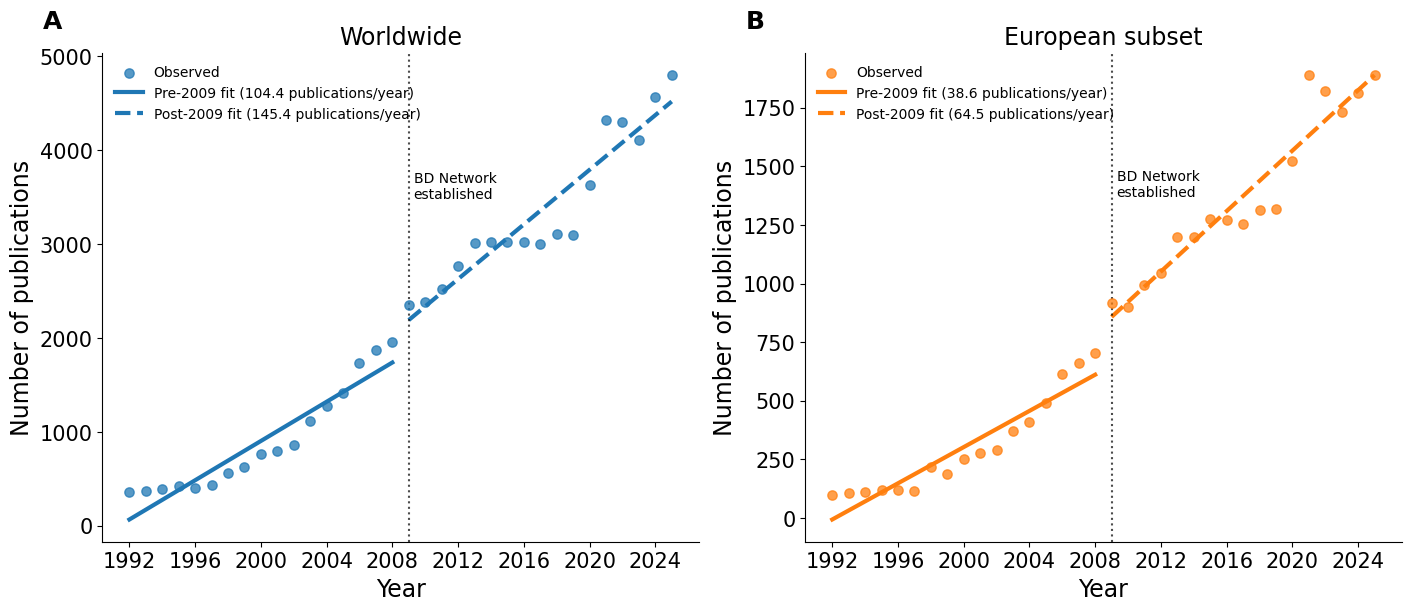

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

fn.plot_segmented_publications(
    axes[0], world_yearly, world_its,
    title='Worldwide', color='tab:blue',
)
fn.plot_segmented_publications(
    axes[1], eu_yearly, eu_its,
    title='European subset', color='tab:orange',
)

axes[0].text(-0.10, 1.05, 'A', transform=axes[0].transAxes,
             fontsize=18, fontweight='bold')
axes[1].text(-0.10, 1.05, 'B', transform=axes[1].transAxes,
             fontsize=18, fontweight='bold')

fig.savefig(FIGURE_DIR / 'Figure1_publication_output.png', dpi=600, bbox_inches='tight')
fig.savefig(FIGURE_DIR / 'Figure1_publication_output.pdf', bbox_inches='tight')
plt.show()

## **Matched post-2009 publication-growth analysis — Figure 2**

The primary longitudinal comparison is restricted to registered BD Network members already active in the European publication dataset before 2009. Random groups of non-Network authors are matched to the BD Network group by pre-2009 publication-productivity strata. The Poisson model is used to estimate APC; inference comes from the empirical randomization distribution.

In [ ]:
growth = fn.run_matched_growth_analysis(
    df_pre_eu,
    df_post_eu,
    author_ids,
    n_simulations=N_SIMULATIONS,
    seed=RANDOM_SEED,
    start_year=INTERVENTION_YEAR,
    end_year=POST_END,
)

print('MATCHED PUBLICATION-GROWTH ANALYSIS')
print('BD Network authors active before 2009:', len(growth['bd_pre_active']))
print('Potential controls:', growth['control_pool_size'])
print('Pre-2009 productivity profile:', growth['bd_profile'])
print(f"Observed BD Network total output: {int(growth['bd_total_output'])}")
print(f"Median matched total output: {growth['matched_total_median']:.1f}")
print(f"Observed BD Network APC: {growth['bd_growth_rate']:.2f}%/year")
print(f"Matched median APC: {growth['matched_growth_median']:.2f}%/year")
print(
    'Matched 95% empirical interval: '
    f"{growth['matched_growth_interval'][0]:.2f}% to "
    f"{growth['matched_growth_interval'][1]:.2f}%"
)
print(f"Difference from matched median: {growth['growth_difference']:.2f} percentage points/year")
print(f"Percentile among matched groups: {growth['percentile_rank']:.2f}%")
print(f"One-sided empirical p (BD > matched): {growth['p_growth_greater']:.6g}")
print(f"Two-sided empirical p: {growth['p_growth_two_sided']:.6g}")

MATCHED PUBLICATION-GROWTH ANALYSIS
BD Network authors active before 2009: 24
Potential controls: 12337
Pre-2009 productivity profile: Counter({'41+': 8, '1-2': 4, '6-10': 4, '11-20': 3, '21-40': 3, '3-5': 2})
Observed BD Network total output: 2697
Median matched total output: 799.0
Observed BD Network APC: 2.53%/year
Matched median APC: -3.48%/year
Matched 95% empirical interval: -8.87% to 0.89%
Difference from matched median: 6.01 percentage points/year
Percentile among matched groups: 99.87%
One-sided empirical p (BD > matched): 0.00139986
Two-sided empirical p: 0.00279972


Panel A uses 10000 of 10000 matched groups with >0 publications in 2009.


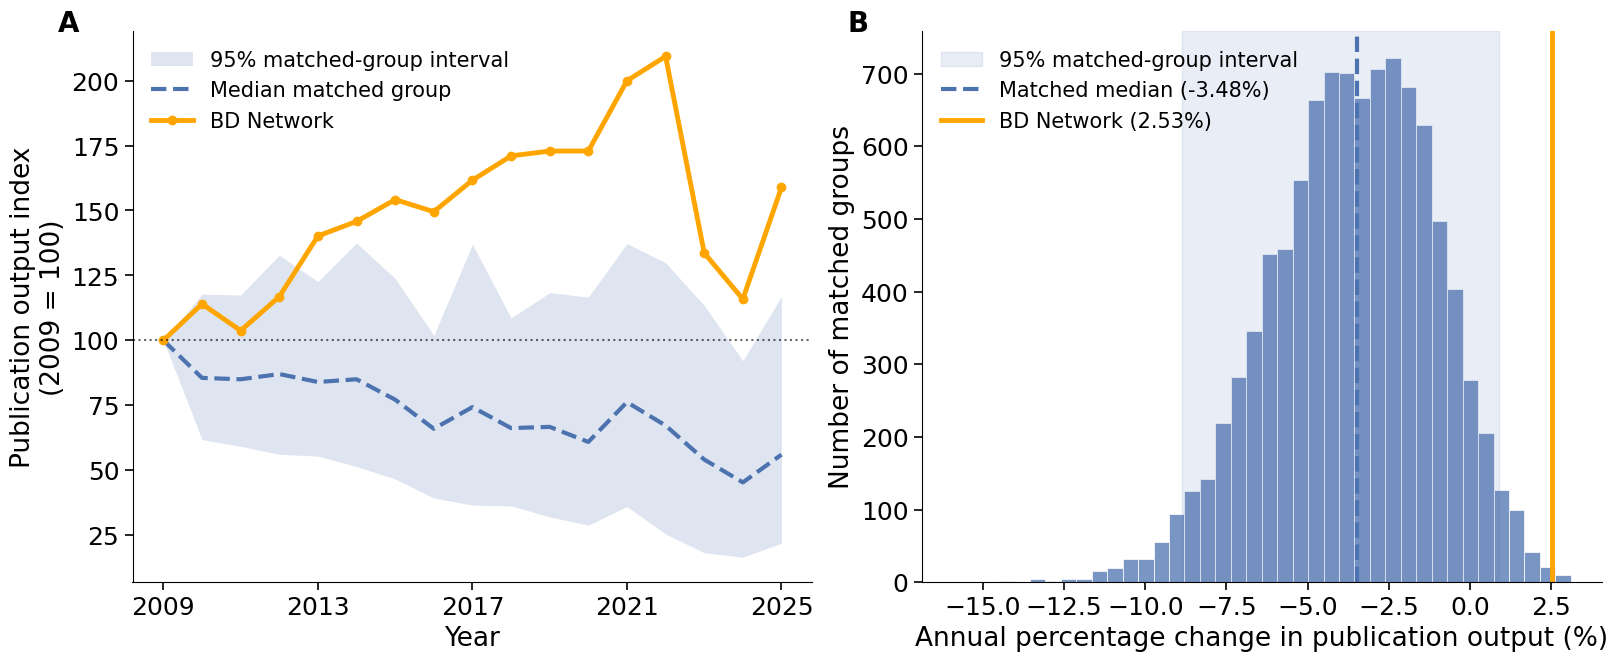

In [ ]:
fig, axes, n_indexable = fn.plot_matched_growth(growth)
print(
    f'Panel A uses {n_indexable} of {growth["n_simulations"]} matched groups '
    'with >0 publications in 2009.'
)

fig.savefig(FIGURE_DIR / 'Figure2_matched_growth.png', dpi=600, bbox_inches='tight')
fig.savefig(FIGURE_DIR / 'Figure2_matched_growth.pdf', bbox_inches='tight')
plt.show()

## **BD Network author productivity — Figure 3**

Annualized Fractional Publication Rate (AFP):


$AFP(a,P) = \frac{F(a,P)}{Y(a,P)}$

where `F(a,P)` is the sum of `1 / n_authors` contributions during period `P`, and `Y(a,P)` is the number of observable years within that period. The primary paired analysis includes only authors with at least five observable years in both periods.

In [ ]:
afp = fn.run_afp_analysis(
    df_pre,
    df_post,
    author_ids,
    first_publication_year,
    min_observable_years=MIN_AFP_YEARS,
)

print('ANNUALIZED FRACTIONAL PUBLICATION RATE')
print('Authors eligible in both periods:', afp['n'])
print(
    f"Pre-Network median = {afp['pre_summary']['median']:.4f}; "
    f"IQR = {afp['pre_summary']['q1']:.4f}–{afp['pre_summary']['q3']:.4f}"
)
print(
    f"Post-Network median = {afp['post_summary']['median']:.4f}; "
    f"IQR = {afp['post_summary']['q1']:.4f}–{afp['post_summary']['q3']:.4f}"
)
print(f"Authors with higher post-Network AFP: {afp['n_increased']} / {afp['n']}")
print(f"Wilcoxon W = {afp['W']:.4f}; p = {afp['p']:.6g}")

display(
    afp['paired'][
        ['AnonID', 'ObservableYears_pre', 'AFP_pre', 'ObservableYears_post', 'AFP_post']
    ].round({'AFP_pre': 4, 'AFP_post': 4})
)

ANNUALIZED FRACTIONAL PUBLICATION RATE
Authors eligible in both periods: 28
Pre-Network median = 0.2336; IQR = 0.0451–0.4715
Post-Network median = 0.7118; IQR = 0.4911–1.3114
Authors with higher post-Network AFP: 27 / 28
Wilcoxon W = 10.0000; p = 3.20375e-07


,AnonID,ObservableYears_pre,AFP_pre,ObservableYears_post,AFP_post
0,A01,17,2.0361,17,4.8172
1,A02,16,1.6246,17,3.4178
2,A03,15,0.0567,17,1.9923
3,A04,8,0.2167,17,1.9495
4,A05,13,0.0085,17,1.5404
5,A06,17,0.9821,17,1.5173
6,A07,14,0.3994,17,1.4749
7,A08,17,0.5676,17,1.2569
8,A09,13,0.3902,17,1.2034
9,A10,17,0.5049,17,1.1573


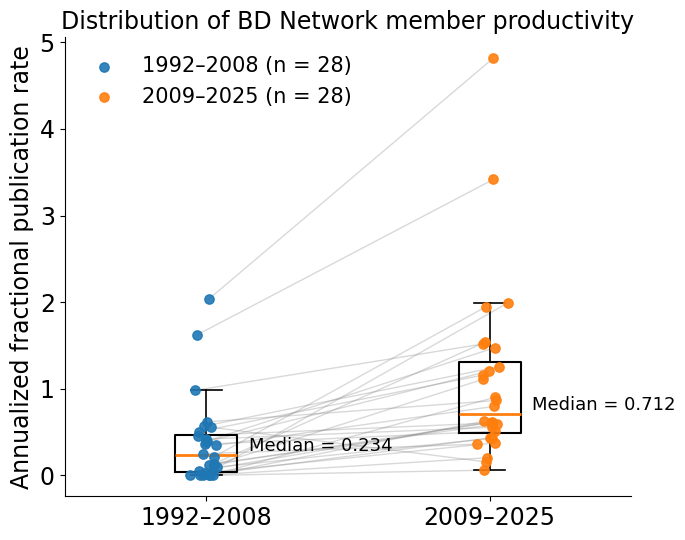

In [ ]:
fig, ax = fn.plot_afp_productivity(afp)
fig.savefig(FIGURE_DIR / 'Figure3_author_productivity.png', dpi=600, bbox_inches='tight')
fig.savefig(FIGURE_DIR / 'Figure3_author_productivity.pdf', bbox_inches='tight')
plt.show()

## **Collaboration network analysis**

Two complementary analyses are retained:

- aggregated co-authorship networks restricted to registered BD Network members (descriptive; Figure 4);
- yearly co-authorship networks across all authors in the European publication subset (inferential pre/post comparison; Table 2).

### **Aggregated BD Network co-authorship networks — Figure 4**

In [ ]:
M_pre = fn.coauthor_matrix(df_pre_bd, author_ids, author_ids)
M_post = fn.coauthor_matrix(df_post_bd, author_ids, author_ids)

# These graphs retain all registered members, including isolates, for descriptive metrics.
G_pre = nx.from_pandas_adjacency(M_pre)
G_post = nx.from_pandas_adjacency(M_post)

aggregate_stats = pd.DataFrame(
    {
        '1992–2008': fn.aggregated_network_stats(G_pre),
        '2009–2025': fn.aggregated_network_stats(G_post),
    }
)

display(aggregate_stats.round(4))

,1992–2008,2009–2025
Nodes,45.0000,45.0000
Edges,24.0000,585.0000
Density,0.0242,0.5909
Average_degree,1.0667,26.0000
Average_weighted_degree,5.4667,239.7778
Weighted_clustering,0.0157,0.0331
Components,29.0000,2.0000
Largest_component,15.0000,44.0000
Average_shortest_path_largest_component,2.7429,1.4091


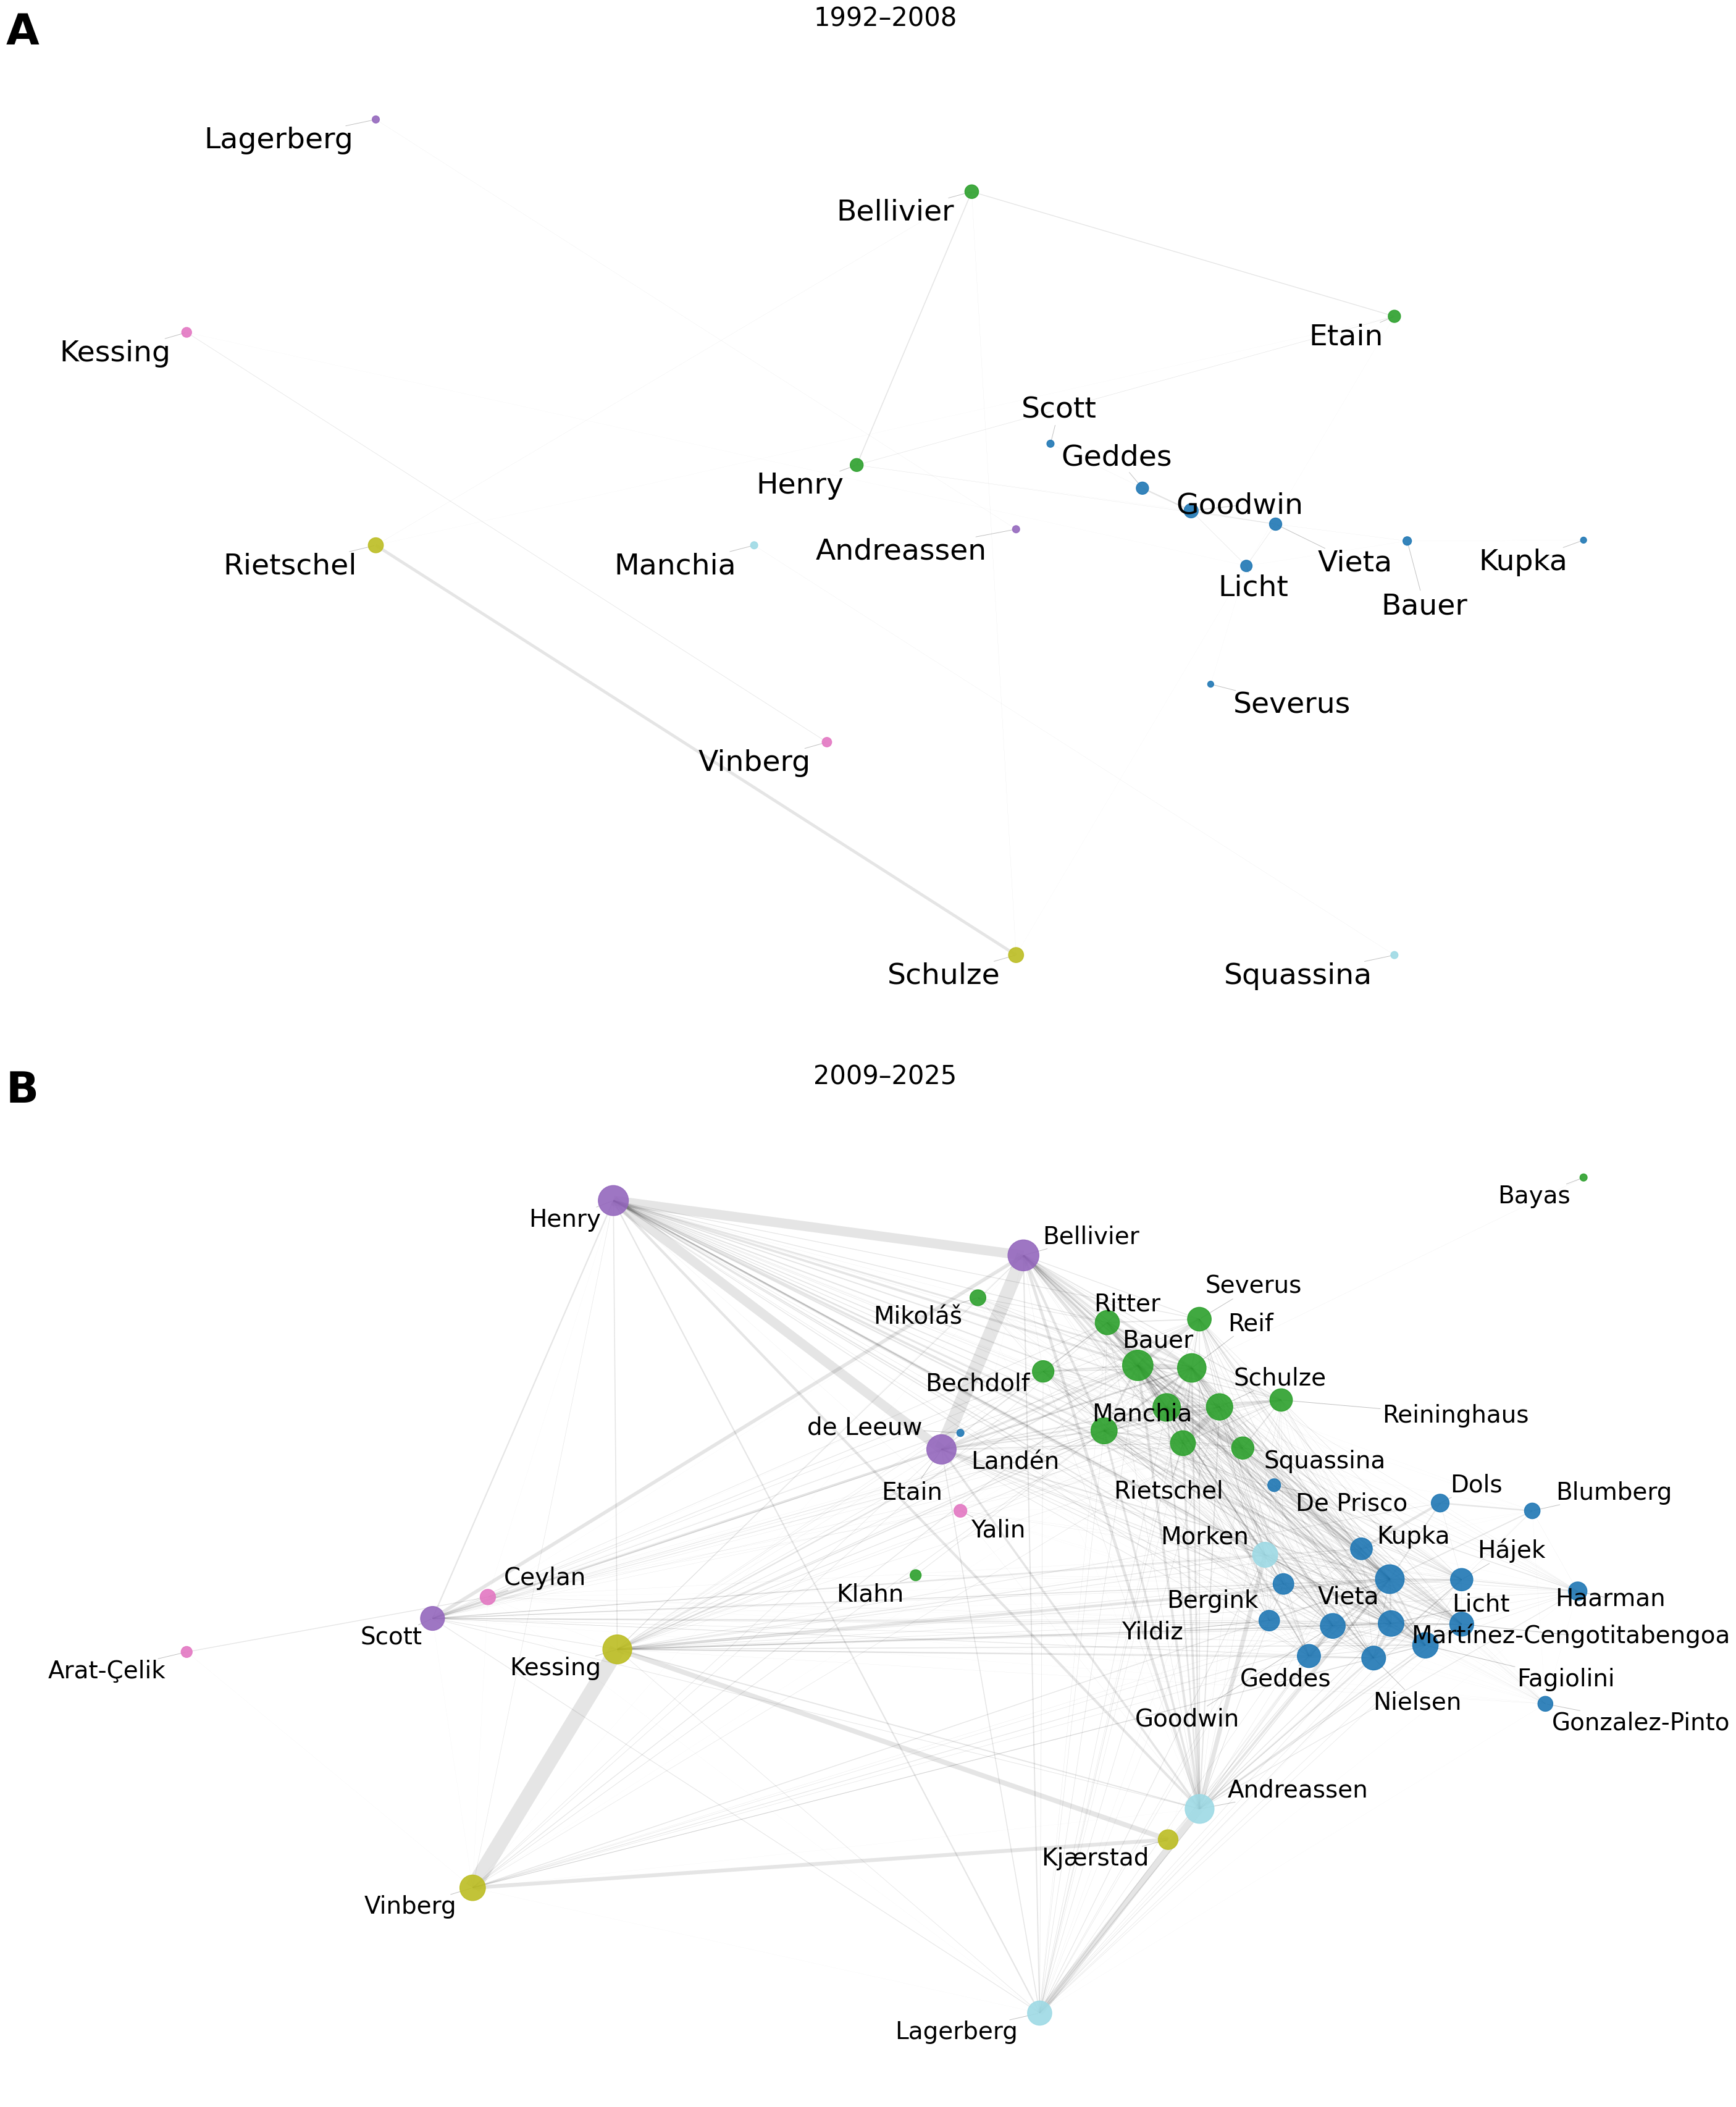

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(28, 34), constrained_layout=True)

# Isolates are omitted from visualization only.
fn.plot_coauthor_network_clustered(
    M_pre,
    min_weight=1,
    cluster_radius=26,
    internal_scale=22.0,
    label_map=id_to_surname,
    font_size=34,
    ax=axes[0],
    title='1992–2008',
    title_font_size=30,
)
axes[0].text(-0.02, 1.02, 'A', transform=axes[0].transAxes,
             fontsize=50, fontweight='bold', va='top')

fn.plot_coauthor_network_clustered(
    M_post,
    min_weight=1,
    cluster_radius=55,
    internal_scale=55,
    label_map=id_to_surname,
    font_size=28,
    ax=axes[1],
    title='2009–2025',
    title_font_size=30,
)
axes[1].text(-0.02, 1.02, 'B', transform=axes[1].transAxes,
             fontsize=50, fontweight='bold', va='top')

fig.savefig(FIGURE_DIR / 'Figure4_BDNet_coauthorship_networks.png', dpi=600, bbox_inches='tight')
fig.savefig(FIGURE_DIR / 'Figure4_BDNet_coauthorship_networks.pdf', bbox_inches='tight')
plt.show()

### **Yearly European co-authorship networks — Table 2**

In [ ]:
network_stats = fn.annual_network_statistics(
    df_total_eu,
    start_year=PRE_START,
    end_year=POST_END,
)

n_pre_networks = (network_stats['Year'] < INTERVENTION_YEAR).sum()
n_post_networks = (network_stats['Year'] >= INTERVENTION_YEAR).sum()
assert n_pre_networks == 17
assert n_post_networks == 17

network_comparison = fn.compare_network_periods(
    network_stats,
    intervention_year=INTERVENTION_YEAR,
)

table2 = fn.manuscript_network_table(network_comparison)

display(table2)

display(
    network_comparison[
        [
            'Metric_label', 'Pre_mean', 'Pre_SD', 'Post_mean', 'Post_SD',
            'U', 'p_raw', 'p_Holm', 'Cohen_d', 'Cliff_delta',
            'Significant_Holm',
        ]
    ].round(6)
)

,Metric,1992–2008 mean ± SD,2009–2025 mean ± SD,Mann–Whitney U,Holm-adjusted p,Cohen's d,Cliff's δ
0,Network density,0.011 ± 0.005,0.003 ± 0.001,280.0,4.75e-06,2.26,0.94
1,Average degree,9.5 ± 2.9,22.2 ± 4.0,1.0,3.53e-06,-3.60,-0.99
2,Average weighted degree,11.2 ± 3.5,25.4 ± 4.8,1.0,3.53e-06,-3.37,-0.99
3,Weighted clustering coefficient,0.14 ± 0.06,0.05 ± 0.01,282.0,4.75e-06,1.83,0.95
4,"Largest connected component, nodes",456 ± 460,4710 ± 1821,0.0,3.53e-06,-3.20,-1.00


,Metric_label,Pre_mean,Pre_SD,Post_mean,Post_SD,U,p_raw,p_Holm,Cohen_d,Cliff_delta,Significant_Holm
0,Network density,0.010840,0.004722,0.003164,0.000896,280.0,0.000003,0.000005,2.258556,0.937716,True
1,Average degree,9.528340,2.944448,22.204831,4.016272,1.0,0.000001,0.000004,-3.599866,-0.993080,True
2,Average weighted degree,11.171277,3.523735,25.411981,4.818842,1.0,0.000001,0.000004,-3.373573,-0.993080,True
3,Weighted clustering coefficient,0.137927,0.063890,0.054277,0.009665,282.0,0.000002,0.000005,1.830776,0.951557,True
4,"Largest connected component, nodes",456.117647,459.561188,4709.823529,1820.669150,0.0,0.000001,0.000004,-3.203607,-1.000000,True


### **Temporal trajectory of weighted clustering**

In [ ]:
network_stats_model, clustering_model, clustering_effects = (
    fn.fit_clustering_temporal_model(network_stats, INTERVENTION_YEAR)
)

print('WEIGHTED CLUSTERING TEMPORAL MODEL')
print(f"Pre-Network slope: {clustering_effects['pre_slope']:.6f} per year")
print(f"Slope change after 2009: {clustering_effects['slope_change']:+.6f} per year")
print(f"Post-Network slope: {clustering_effects['post_slope']:.6f} per year")
print(f"Time × Post p-value: {clustering_effects['interaction_p']:.6g}")

display(fn.model_coefficient_table(clustering_model).round(6))

WEIGHTED CLUSTERING TEMPORAL MODEL
Pre-Network slope: -0.009108 per year
Slope change after 2009: +0.007841 per year
Post-Network slope: -0.001266 per year
Time × Post p-value: 0.00185996


,Coefficient,SE,p,CI_low,CI_high
Intercept,0.055959,0.016648,0.002130,0.021959,0.089959
Time,-0.009108,0.001625,0.000004,-0.012426,-0.005790
Post,0.008448,0.022571,0.710820,-0.037648,0.054544
Time:Post,0.007841,0.002298,0.001860,0.003149,0.012534
